# CP-322-Assignment 1 Q2

**Jordan Tauro, Clinton Osawe, Visula Jayasinghe, Philip Marian**

In this question, we used decision trees to classify news headlines as real or fake. We compared different maximum depths using the validation set, tested the best model, and looked at the first two layers of the tree.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.tree import DecisionTreeClassifier, export_text


## (a) Load data and extract features


In [2]:
def load_data():
    with open("Decision Tree-Dataset/real.txt", "r", encoding="utf-8") as file:
        real_headlines = [line.strip() for line in file if line.strip()]
    with open("Decision Tree-Dataset/fake.txt", "r", encoding="utf-8") as file:
        fake_headlines = [line.strip() for line in file if line.strip()]

    headlines = real_headlines + fake_headlines
    labels = np.array([1] * len(real_headlines) + [0] * len(fake_headlines))

    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(headlines)

    rng = np.random.default_rng(42)
    indices = rng.permutation(len(headlines))
    X, labels = X[indices], labels[indices]

    n = len(labels)
    train_end = int(0.70 * n)
    validation_end = int(0.85 * n)

    X_train, y_train = X[:train_end], labels[:train_end]
    X_validation, y_validation = X[train_end:validation_end], labels[train_end:validation_end]
    X_test, y_test = X[validation_end:], labels[validation_end:]

    print("Training examples:", len(y_train))
    print("Validation examples:", len(y_validation))
    print("Test examples:", len(y_test))
    return X_train, y_train, X_validation, y_validation, X_test, y_test, vectorizer


## (b) Model selection


In [3]:
def select_model(X_train, y_train, X_validation, y_validation, X_test, y_test):
    depths = [2, 5, 10, 20, 50, 100, 150, 200, 300]
    validation_accuracies = []

    for depth in depths:
        model = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=42)
        model.fit(X_train, y_train)
        predictions = model.predict(X_validation)
        accuracy = np.mean(predictions == y_validation)
        validation_accuracies.append(accuracy)
        print("max_depth =", depth, "validation accuracy:", accuracy)

    best_depth = depths[np.argmax(validation_accuracies)]
    best_model = DecisionTreeClassifier(criterion="entropy", max_depth=best_depth, random_state=42)
    best_model.fit(X_train, y_train)

    test_accuracy = np.mean(best_model.predict(X_test) == y_test)
    print("\nBest max_depth:", best_depth)
    print("Actual depth of the trained tree:", best_model.get_depth())
    print("Test accuracy:", test_accuracy)

    plt.plot(depths, validation_accuracies, marker="o")
    plt.xlabel("max_depth")
    plt.ylabel("Validation accuracy")
    plt.title("Validation accuracy vs. max_depth")
    plt.grid(True)
    plt.show()
    return best_model


## (c) First two layers of the selected tree


In [4]:
def visualize_tree(best_model, vectorizer):
    feature_names = vectorizer.get_feature_names_out()
    tree_text = export_text(best_model, feature_names=list(feature_names), max_depth=1)
    print("\nFirst Two Layers of Best Decision Tree:")
    print(tree_text)
    return tree_text


## Run all Q2 code


Training examples: 2286
Validation examples: 490
Test examples: 490
max_depth = 2 validation accuracy: 0.6
max_depth = 5 validation accuracy: 0.7183673469387755
max_depth = 10 validation accuracy: 0.7244897959183674
max_depth = 20 validation accuracy: 0.7428571428571429
max_depth = 50 validation accuracy: 0.7489795918367347


max_depth = 100 validation accuracy: 0.773469387755102
max_depth = 150 validation accuracy: 0.773469387755102
max_depth = 200 validation accuracy: 0.773469387755102


max_depth = 300 validation accuracy: 0.773469387755102

Best max_depth: 100
Actual depth of the trained tree: 100
Test accuracy: 0.7551020408163265


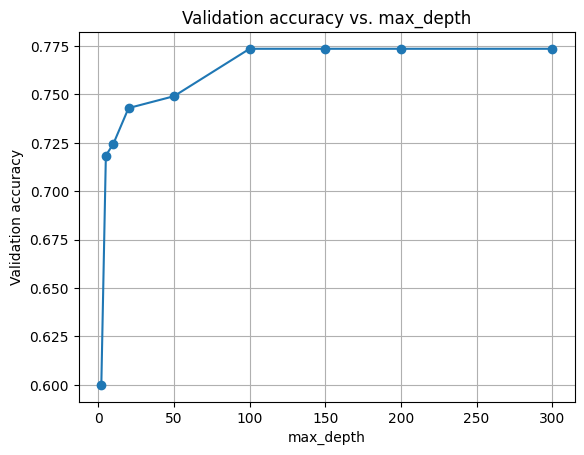


First Two Layers of Best Decision Tree:
|--- donald <= 0.50
|   |--- trumps <= 0.50
|   |   |--- truncated branch of depth 99
|   |--- trumps >  0.50
|   |   |--- truncated branch of depth 4
|--- donald >  0.50
|   |--- the <= 0.50
|   |   |--- truncated branch of depth 34
|   |--- the >  0.50
|   |   |--- truncated branch of depth 25



In [5]:
X_train, y_train, X_validation, y_validation, X_test, y_test, vectorizer = load_data()
best_model = select_model(X_train, y_train, X_validation, y_validation, X_test, y_test)
tree_text = visualize_tree(best_model, vectorizer)


## What we found

Our validation accuracy increased from **60%** at a maximum depth of 2 to **77.35%** at a depth of 100. The accuracy stayed the same at depths 150, 200, and 300, so we chose **100** as the smallest depth with the highest validation accuracy. On the separate test set, our model reached **75.51%** accuracy.

When we looked at the first two layers of the best tree, the first split checked the word **“donald.”** The next split checked either **“trumps”** or **“the,”** depending on the first result.
